Class distribution:
Class
1    225
0    126
Name: count, dtype: int64
Training set shape: (280, 33), (280,)
Test set shape: (71, 33), (71,)
Basic statistics:
               V1          V3          V4          V5          V6          V7  \
count  351.000000  351.000000  351.000000  351.000000  351.000000  351.000000   
mean     0.891738    0.641342    0.044372    0.601068    0.115889    0.550095   
std      0.311155    0.497708    0.441435    0.519862    0.460810    0.492654   
min      0.000000   -1.000000   -1.000000   -1.000000   -1.000000   -1.000000   
25%      1.000000    0.472135   -0.064735    0.412660   -0.024795    0.211310   
50%      1.000000    0.871110    0.016310    0.809200    0.022800    0.728730   
75%      1.000000    1.000000    0.194185    1.000000    0.334655    0.969240   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

               V8          V9         V10         V11  ...         V25  \
count  351.000000  351.000000  351.000

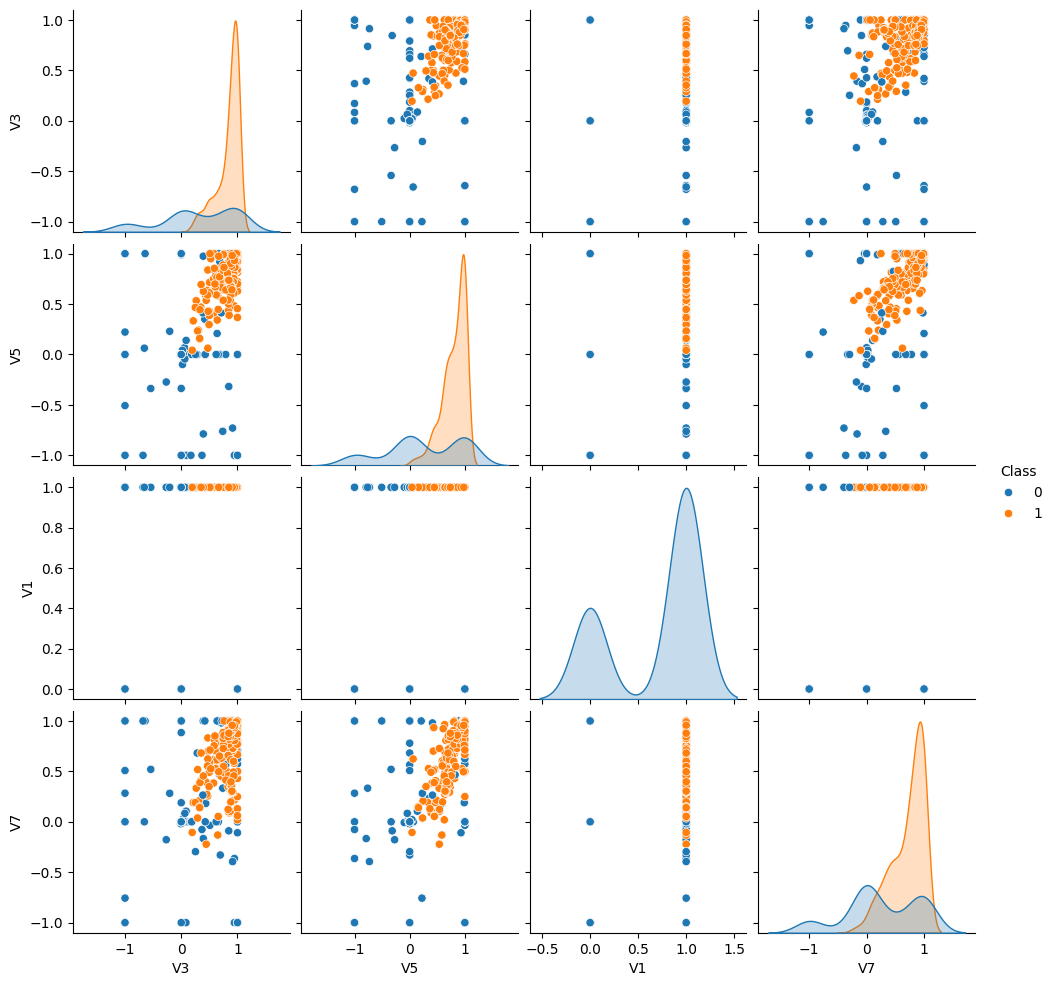

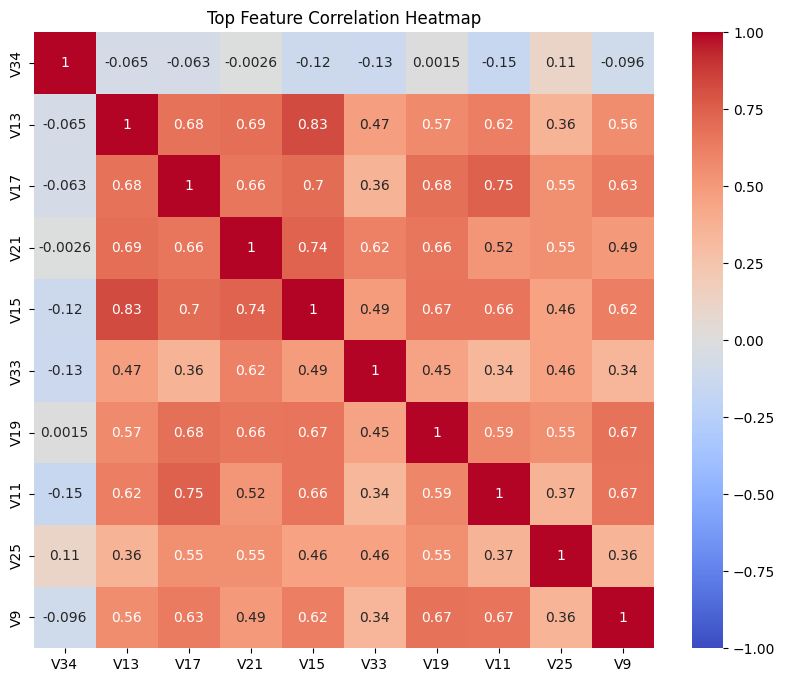

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

class NaiveBayesScratch:
    def __init__(self):
        self.classes = None
        self.mean = {}
        self.variance = {}
        self.priors = {}

    def fit(self, X, Y):
        self.classes = Y.unique()
        self.class_prior = {c: 0 for c in self.classes}  # Initialize class prior

        # Calculate class prior probabilities
        total_samples = len(Y)
        for c in self.classes:
            self.class_prior[c] = len(Y[Y == c]) / total_samples

        # Now calculate mean and variance as well (assuming you have the following lines)
        self.mean = {c: X[Y == c].mean() for c in self.classes}
        self.variance = {c: X[Y == c].var() for c in self.classes}

    def calculate_probability(self, x, mean, var):
        eps = 1e-6  # avoid division by zero
        # print(f"x: {x}, mean: {mean}, var: {var}")  # Debugging line
        numerator = np.exp(-((x - mean) ** 2) / (2 * var + eps))
        denominator = np.sqrt(2 * np.pi * var + eps)
        return numerator / denominator

    def predict(self, X):
        predictions = [self._predict(X.iloc[i]) for i in range(len(X))]
        return predictions

    def _predict(self, x):
        probabilities = {}
        for c in self.classes:
            probabilities[c] = self.class_prior[c]
            for feature in x.index:  # Ensure you use the feature values correctly
                probabilities[c] *= self.calculate_probability(
                    x[feature], self.mean[c][feature], self.variance[c][feature]
                )
        return max(probabilities, key=probabilities.get)


# Read data from the CSV file
data = pd.read_csv("./ion_binary_classification.csv")

# Drop the 'Unnamed: 0' column and convert 'Class' to binary
data = data.drop(columns=["Unnamed: 0"])  # Drop the unnecessary index column
data = data.drop(
    columns=["V2"]
)  # Dropping V2 column as it has same value for all the records
data["Class"] = data["Class"].map(
    {"good": 1, "bad": 0}
)  # Convert 'good' to 1 and 'bad' to 0

# Convert 'V1' to integer type (assuming they are valid integers)
data["V1"] = data["V1"].astype(int)

# Split dataset into features (X) and target (Y)
X = data.drop(columns=["Class"])
Y = data["Class"]

# Check the distribution of 'good' and 'bad' classes
print("Class distribution:")
print(Y.value_counts())

# Check for zero-variance features
zero_variance_features = X.columns[X.std() == 0]

# Create a binary indicator for the zero-variance feature
for feature in zero_variance_features:
    X[f"{feature}_flag"] = (X[feature] != 0).astype(
        int
    )  # Flagging if the original feature is not zero

# Now, you can proceed to split the dataset
train_size = int(0.8 * len(data))
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# Fill NaN values or drop them
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

# Print the shapes of the splits
print(f"Training set shape: {X_train.shape}, {Y_train.shape}")
print(f"Test set shape: {X_test.shape}, {Y_test.shape}")

# Basic statistics of the data
print("Basic statistics:")
print(X.describe())

# Visualization: Pair plot of the first few features and the class label
# Temporarily concatenate X (features) and Y (target) for visualization
zero_variance_features = X.columns[X.std() == 0]
print(f"Features with zero variance: {zero_variance_features}")

# Drop zero variance features (if any)
X_filtered = X.drop(columns=zero_variance_features)

# Handle any NaN values by replacing them (optional: you can also drop or impute)
X_filtered = X_filtered.fillna(
    X_filtered.mean()
)  # Replace NaNs with mean (you can also use median or other strategies)

# Recalculate correlations with the target ('Class') using cleaned data
corr_with_target = X_filtered.corrwith(Y.replace({"good": 1, "bad": 0})).abs()

# Select the top 4 most correlated features with the target
top_corr_features_with_target = (
    corr_with_target.sort_values(ascending=False).head(4).index
)

# Create the new DataFrame for the pair plot
data_visual_top = pd.concat([X_filtered[top_corr_features_with_target], Y], axis=1)

# Plot the pair plot using the refined DataFrame
sns.pairplot(data_visual_top, hue="Class")
plt.show()


# Correlation heatmap
# Calculate the correlation matrix
corr_matrix = X.corr()

# Select the top 10 most correlated features (highest absolute correlations)
top_corr_features = (
    corr_matrix.abs().unstack().sort_values(ascending=False).drop_duplicates()
)
top_features = (
    top_corr_features[top_corr_features > 0.5].index.get_level_values(0).unique()[:10]
)  # Adjust threshold as needed

# Plot heatmap for these top features
plt.figure(figsize=(10, 8))  # Increase figure size if needed
sns.heatmap(X[top_features].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Top Feature Correlation Heatmap")
plt.show()

Accuracy: 74.65%
Precision: 100.00%
Recall: 74.65%
F1 Score: 85.48%


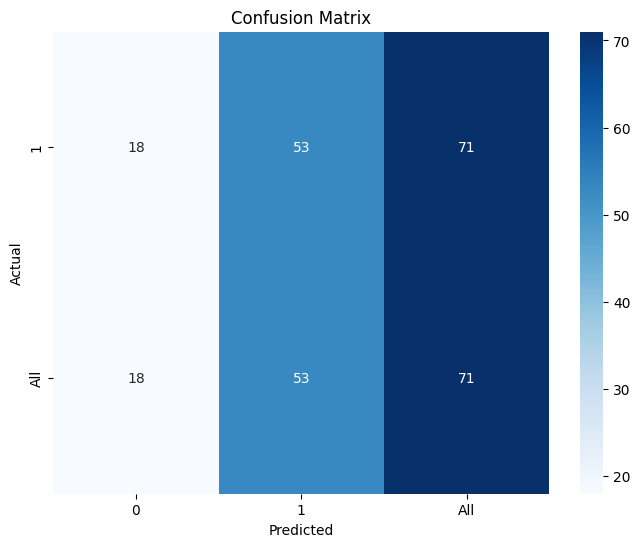

/home/satish/Personal/ml-assignment/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1174: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


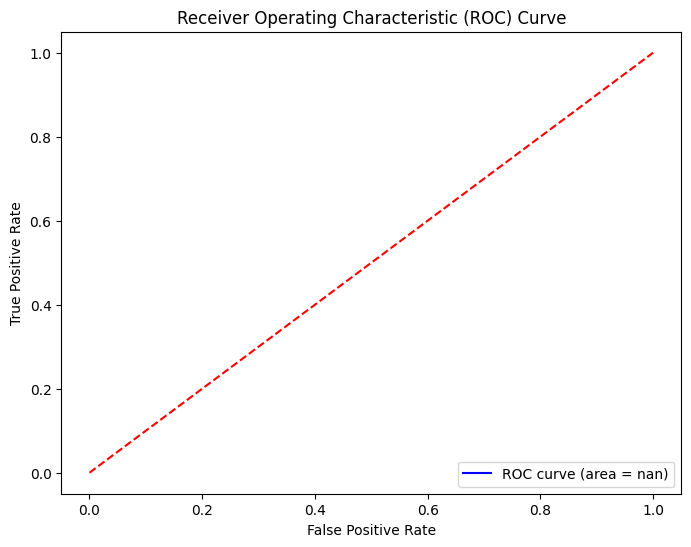

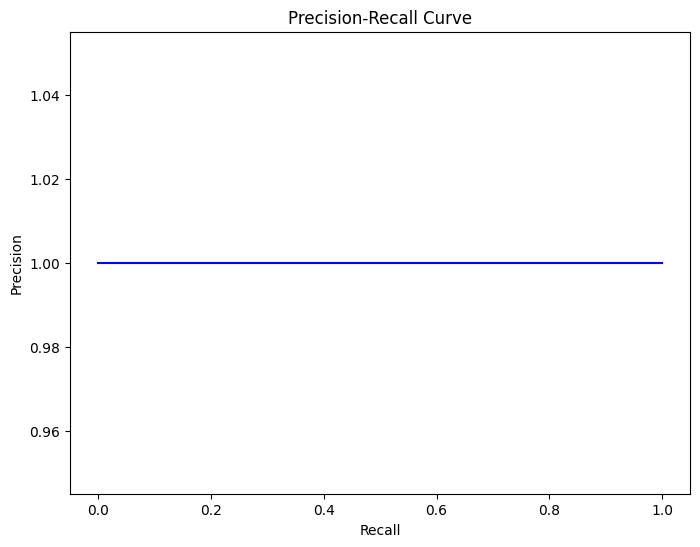

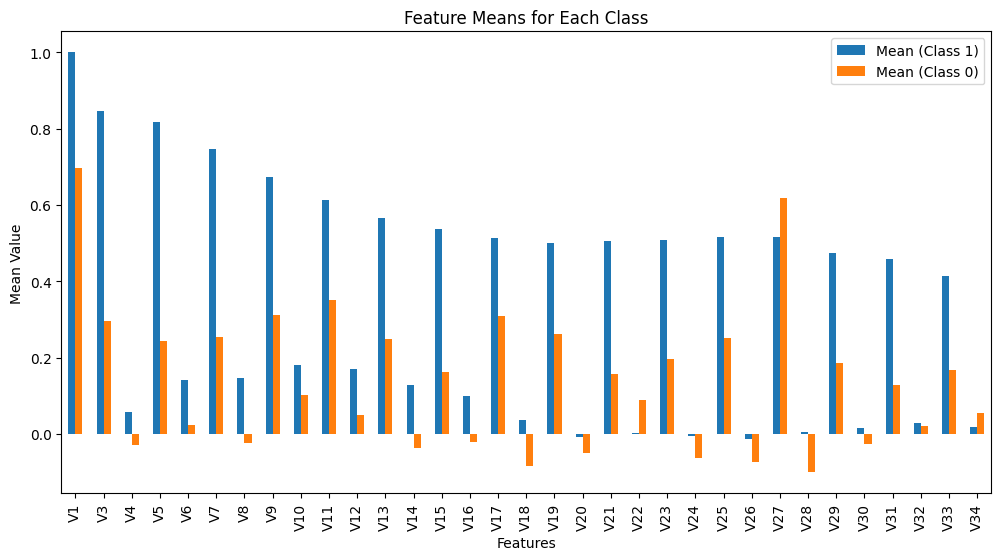

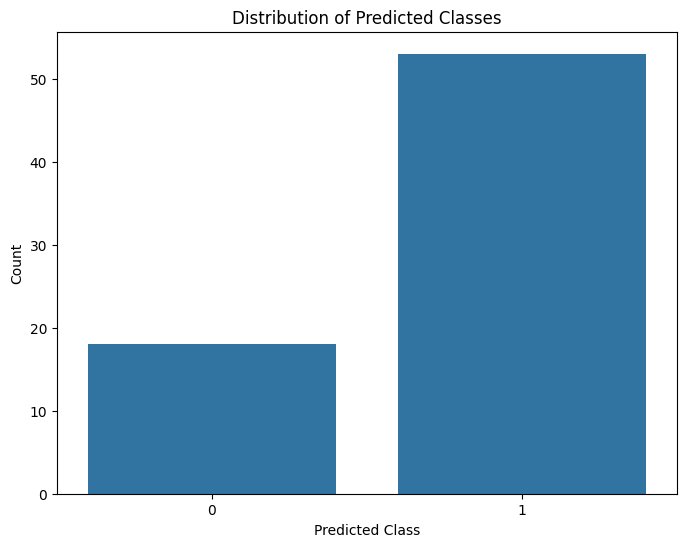

/tmp/ipykernel_8492/3585644814.py:116: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


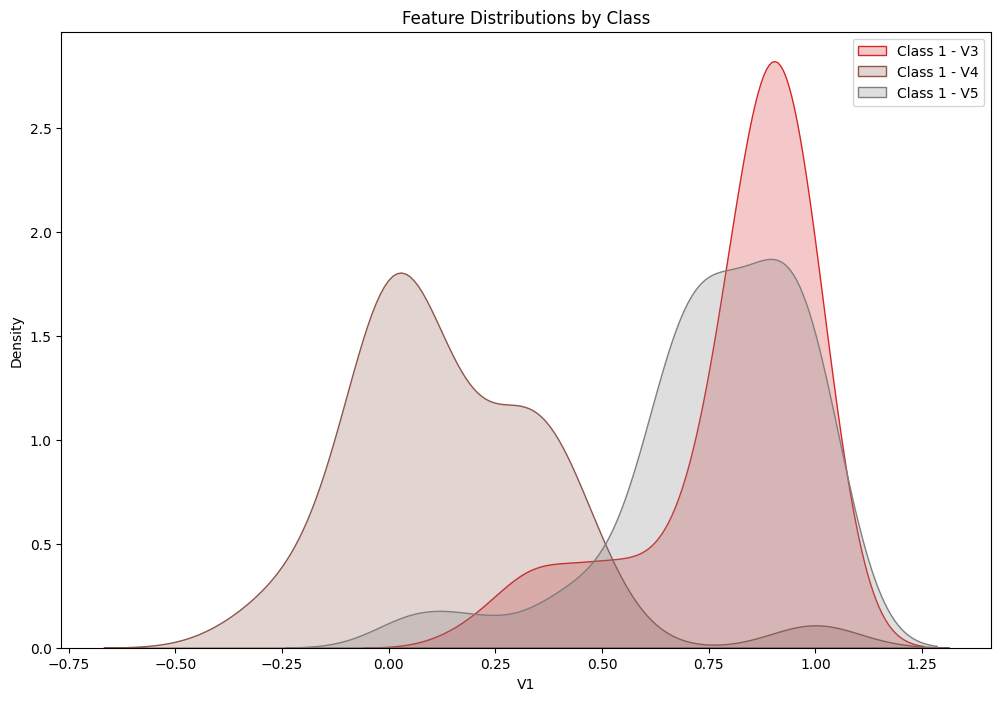

In [31]:
# Calculate Confusion Matrix elements manually
def confusion_matrix_manual(actual, predicted):
    TP = sum((actual == 1) & (predicted == 1))  # True Positives
    TN = sum((actual == 0) & (predicted == 0))  # True Negatives
    FP = sum((actual == 0) & (predicted == 1))  # False Positives
    FN = sum((actual == 1) & (predicted == 0))  # False Negatives
    return TP, TN, FP, FN


# Calculate Precision, Recall, and F1-Score manually
def precision_recall_f1(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0
    )
    return precision, recall, f1


# Model training
nb_scratch = NaiveBayesScratch()
nb_scratch.fit(X_train, Y_train)

# Model prediction
y_pred = nb_scratch.predict(X_test)

# Calculate accuracy
accuracy = np.mean(y_pred == Y_test)

TP, TN, FP, FN = confusion_matrix_manual(np.array(Y_test), np.array(y_pred))

# Calculate Precision, Recall, and F1 Score
precision, recall, f1 = precision_recall_f1(TP, FP, FN)

# Create confusion matrix
confusion_matrix = pd.crosstab(
    Y_test, y_pred, rownames=["Actual"], colnames=["Predicted"], margins=True
)


print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")


# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()


# Calculate Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(Y_test, y_pred)

# Plotting the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color="blue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


# Assuming you have stored the means and variances for each feature
feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Mean (Class 1)": [nb_scratch.mean[1][feature] for feature in X.columns],
        "Mean (Class 0)": [nb_scratch.mean[0][feature] for feature in X.columns],
    }
)

# Plotting feature means
feature_importance.set_index("Feature").plot(kind="bar", figsize=(12, 6))
plt.title("Feature Means for Each Class")
plt.ylabel("Mean Value")
plt.xlabel("Features")
plt.show()


plt.figure(figsize=(8, 6))
sns.countplot(x=y_pred)
plt.title("Distribution of Predicted Classes")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(12, 8))
for feature in X.columns[:4]:  # Example with the first 4 features
    # Use `iloc` to get the positional indices of Y_test
    sns.kdeplot(
        X.iloc[Y_test.index][feature][Y_test == 0],
        label=f"Class 0 - {feature}",
        fill=True,
    )
    sns.kdeplot(
        X.iloc[Y_test.index][feature][Y_test == 1],
        label=f"Class 1 - {feature}",
        fill=True,
    )
plt.title("Feature Distributions by Class")
plt.legend()
plt.show()